# Análisis Exploratorio de Datos - Mercado Inmobiliario Airbnb
**Actividad Evaluable - Fase 1: EDA**

**Nombre:** Ana Sarai Zuñiga Esquivel.
**Fecha:** Abril 2026
**Dataset:** Airbnb Price Prediction (Kaggle)

---

## Introducción
En este notebook realize un análisis exploratorio de datos (EDA) sobre el mercado inmobiliario de Airbnb. El objetivo es entender la distribución de los datos, identificar variables clave que afectan el precio, y detectar posibles anomalías o patrones relevantes.

Dataset: https://www.kaggle.com/datasets/stevezhenghp/airbnb-price-prediction

---
## Parte 1: Carga de datos e importación de librerías

In [ ]:
!pip install seaborn

In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Librerías importadas correctamente')
print(f'pandas  v{pd.__version__}')
print(f'numpy   v{np.__version__}')
print(f'seaborn v{sns.__version__}')

Librerías importadas correctamente
pandas  v3.0.1
numpy   v2.4.3
seaborn v0.13.2


In [3]:
# Carga del dataset
# Descargar desde: https://www.kaggle.com/datasets/stevezhenghp/airbnb-price-prediction
# Colocar train.csv en la misma carpeta que este notebook

df = pd.read_csv('train.csv', low_memory=False)

print('Dataset cargado sin errores')
print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')

Dataset cargado sin errores
Filas:    74,111
Columnas: 29


In [4]:
# Primer vistazo
df.head(10)

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0
5,12422935,4.442651,Apartment,Private room,"{TV,""Wireless Internet"",Heating,""Smoke detecto...",2,1.0,Real Bed,strict,True,...,37.753164,-122.429526,Comfort Suite San Francisco,Noe Valley,3,100.0,https://a0.muscache.com/im/pictures/82509143-4...,94131,1.0,1.0
6,11825529,4.418841,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",3,1.0,Real Bed,moderate,True,...,33.980454,-118.462821,Beach Town Studio and Parking!!!11h,NaN,15,97.0,https://a0.muscache.com/im/pictures/4c920c60-4...,90292,1.0,1.0
7,13971273,4.787492,Condominium,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Wheelchair...",2,1.0,Real Bed,moderate,True,...,34.046737,-118.260439,"Near LA Live, Staple's. Starbucks inside. OWN ...",Downtown,9,93.0,https://a0.muscache.com/im/pictures/61bd05d5-c...,90015,1.0,1.0
8,180792,4.787492,House,Private room,"{TV,""Cable TV"",""Wireless Internet"",""Pets live ...",2,1.0,Real Bed,moderate,True,...,37.781128,-122.501095,Cozy Garden Studio - Private Entry,Richmond District,159,99.0,https://a0.muscache.com/im/pictures/0ed6c128-7...,94121,1.0,1.0
9,5385260,3.583519,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",2,1.0,Real Bed,moderate,True,...,33.992563,-117.895997,No.7 Queen Size Cozy Room 舒适大床房,NaN,2,90.0,https://a0.muscache.com/im/pictures/8d2f08ce-b...,91748,1.0,1.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  str    
 3   room_type               74111 non-null  str    
 4   amenities               74111 non-null  str    
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  str    
 8   cancellation_policy     74111 non-null  str    
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  str    
 11  description             74111 non-null  str    
 12  first_review            58247 non-null  str    
 13  host_has_profile_pic    73923 non-null  str    
 14  host_identity_verified  73923 non-null  str    
 

In [7]:
# Preparación de la variable precio
# El dataset usa log_price como target; la convertimos a precio real
if 'log_price' in df.columns:
    df['price'] = np.exp(df['log_price'])
    print('Columna price creada desde log_price')
elif 'price' in df.columns:
    if df['price'].dtype == object:
        df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
    print('Columna price disponible directamente')

print(f'Min: ${df["price"].min():.2f} | Max: ${df["price"].max():.2f}')
print(f'Media: ${df["price"].mean():.2f} | Mediana: ${df["price"].median():.2f}')

Columna price creada desde log_price
Min: $1.00 | Max: $1999.00
Media: $160.37 | Mediana: $111.00


---
## Parte 2: Análisis Exploratorio de Datos (EDA)
### 2.1 Análisis Descriptivo

In [8]:
# Estadísticas descriptivas generales
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
id,74111.0,11266617.10,6081734.89,344.00,6261964.50,12254147.00,16402260.50,21230903.00
log_price,74111.0,4.78,0.72,0.00,4.32,4.71,5.22,7.60
accommodates,74111.0,3.16,2.15,1.00,2.00,2.00,4.00,16.00
bathrooms,73911.0,1.24,0.58,0.00,1.00,1.00,1.00,8.00
latitude,74111.0,38.45,3.08,33.34,34.13,40.66,40.75,42.39
longitude,74111.0,-92.40,21.71,-122.51,-118.34,-77.00,-73.95,-70.99
number_of_reviews,74111.0,20.90,37.83,0.00,1.00,6.00,23.00,605.00
review_scores_rating,57389.0,94.07,7.84,20.00,92.00,96.00,100.00,100.00
bedrooms,74020.0,1.27,0.85,0.00,1.00,1.00,1.00,10.00
beds,73980.0,1.71,1.25,0.00,1.00,1.00,2.00,18.00


In [9]:
# Estadísticas univariadas: media, mediana, moda, desviación estándar
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

stats = []
for col in num_cols:
    stats.append({
        'Variable':       col,
        'Media':          round(df[col].mean(), 3),
        'Mediana':        round(df[col].median(), 3),
        'Moda':           round(df[col].mode()[0], 3) if not df[col].mode().empty else None,
        'Desv. Std':      round(df[col].std(), 3),
        'Mínimo':         round(df[col].min(), 3),
        'Máximo':         round(df[col].max(), 3),
        'Asimetría':      round(df[col].skew(), 3),
        'Valores Nulos':  int(df[col].isnull().sum())
    })

pd.DataFrame(stats).set_index('Variable')

,Media,Mediana,Moda,Desv. Std,Mínimo,Máximo,Asimetría,Valores Nulos
Variable,,,,,,,,
id,1.126662e+07,1.225415e+07,344.000,6081734.887,344.000,2.123090e+07,-0.261,0
log_price,4.782000e+00,4.710000e+00,5.011,0.717,0.000,7.600000e+00,0.515,0
accommodates,3.155000e+00,2.000000e+00,2.000,2.154,1.000,1.600000e+01,2.232,0
bathrooms,1.235000e+00,1.000000e+00,1.000,0.582,0.000,8.000000e+00,3.691,200
latitude,3.844600e+01,4.066200e+01,33.339,3.080,33.339,4.239000e+01,-0.535,0
longitude,-9.239800e+01,-7.699700e+01,-122.511,21.705,-122.511,-7.098500e+01,-0.407,0
number_of_reviews,2.090100e+01,6.000000e+00,0.000,37.829,0.000,6.050000e+02,3.703,0
review_scores_rating,9.406700e+01,9.600000e+01,100.000,7.837,20.000,1.000000e+02,-3.381,16722
bedrooms,1.266000e+00,1.000000e+00,1.000,0.852,0.000,1.000000e+01,1.990,91


In [10]:
# Valores nulos
null_df = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    '% Total': (df.isnull().mean() * 100).round(2)
})
null_df = null_df[null_df['Nulos'] > 0].sort_values('Nulos', ascending=False)
print('=== Valores Nulos ===')
print(null_df.to_string() if not null_df.empty else 'No hay valores nulos.')

=== Valores Nulos ===
                        Nulos  % Total
host_response_rate      18299    24.69
review_scores_rating    16722    22.56
first_review            15864    21.41
last_review             15827    21.36
thumbnail_url            8216    11.09
neighbourhood            6872     9.27
zipcode                   966     1.30
bathrooms                 200     0.27
host_has_profile_pic      188     0.25
host_identity_verified    188     0.25
host_since                188     0.25
beds                      131     0.18
bedrooms                   91     0.12


In [11]:
# Correlación con el precio: identificación de variables clave
correlaciones = df[num_cols].corr()['price'].drop('price').abs().sort_values(ascending=False)
print('=== Correlación Absoluta con el Precio (Top 10) ===')
print(correlaciones.head(10).to_string())
print('\nEstas son las variables candidatas a ser más influyentes en el precio.')

=== Correlación Absoluta con el Precio (Top 10) ===
log_price               0.840001
accommodates            0.519326
bedrooms                0.494437
bathrooms               0.459350
beds                    0.433162
number_of_reviews       0.070956
review_scores_rating    0.067100
longitude               0.057601
latitude                0.031344
id                      0.002698

Estas son las variables candidatas a ser más influyentes en el precio.


In [12]:
# Variables categóricas
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Variables categóricas ({len(cat_cols)}):' )
for col in cat_cols:
    n_u = df[col].nunique()
    top = df[col].value_counts().index[0]
    pct = df[col].value_counts(normalize=True).values[0] * 100
    print(f'  {col:<30} | {n_u:>4} únicos | Top: "{top}" ({pct:.1f}%)')

Variables categóricas (18):
  property_type                  |   35 únicos | Top: "Apartment" (66.1%)
  room_type                      |    3 únicos | Top: "Entire home/apt" (55.7%)
  amenities                      | 67122 únicos | Top: "{}" (0.8%)
  bed_type                       |    5 únicos | Top: "Real Bed" (97.2%)
  cancellation_policy            |    5 únicos | Top: "strict" (43.7%)
  city                           |    6 únicos | Top: "NYC" (43.6%)
  description                    | 73479 únicos | Top: "Hello, I've been running guest house for Koreans visiting U.S. for 3years, and recently decided to run this place for other travelers also. There are 10 room in the house. They are mostly dormitory rooms and couple of couple room and family room. This places are our women's dormitory in third floor. There are three rooms, but no doors. It is basically open space. There are 2 beds in two rooms and 4 in one room. I do not have closet in this room but there are hangers and mini she

---
### 2.2 Visualización de Datos
#### A) Histogramas

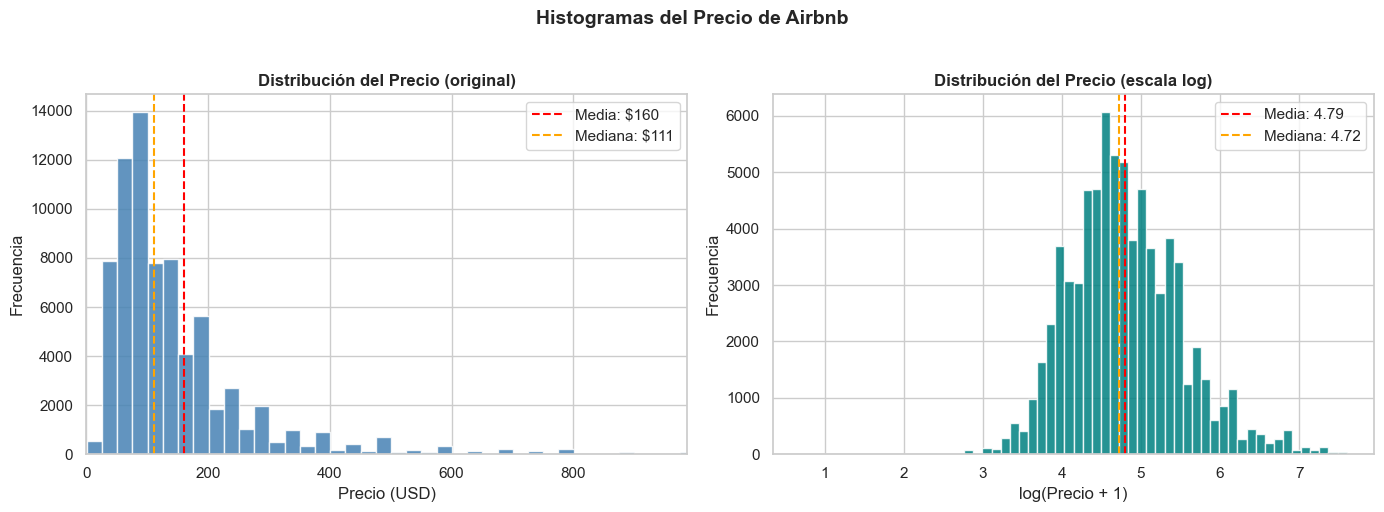

Observación: El precio tiene distribución muy sesgada a la derecha.
La transformación logarítmica produce una distribución más simétrica,
lo cual es conveniente para modelos de regresión.


In [13]:
# Histograma del precio (original y escala log)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'].dropna(), bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución del Precio (original)', fontweight='bold')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['price'].mean(),   color='red',    linestyle='--', label=f'Media: ${df["price"].mean():.0f}')
axes[0].axvline(df['price'].median(), color='orange', linestyle='--', label=f'Mediana: ${df["price"].median():.0f}')
axes[0].set_xlim(0, df['price'].quantile(0.99))
axes[0].legend()

log_p = np.log1p(df['price'].dropna())
axes[1].hist(log_p, bins=60, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribución del Precio (escala log)', fontweight='bold')
axes[1].set_xlabel('log(Precio + 1)')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(log_p.mean(),   color='red',    linestyle='--', label=f'Media: {log_p.mean():.2f}')
axes[1].axvline(log_p.median(), color='orange', linestyle='--', label=f'Mediana: {log_p.median():.2f}')
axes[1].legend()

plt.suptitle('Histogramas del Precio de Airbnb', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Observación: El precio tiene distribución muy sesgada a la derecha.')
print('La transformación logarítmica produce una distribución más simétrica,')
print('lo cual es conveniente para modelos de regresión.')

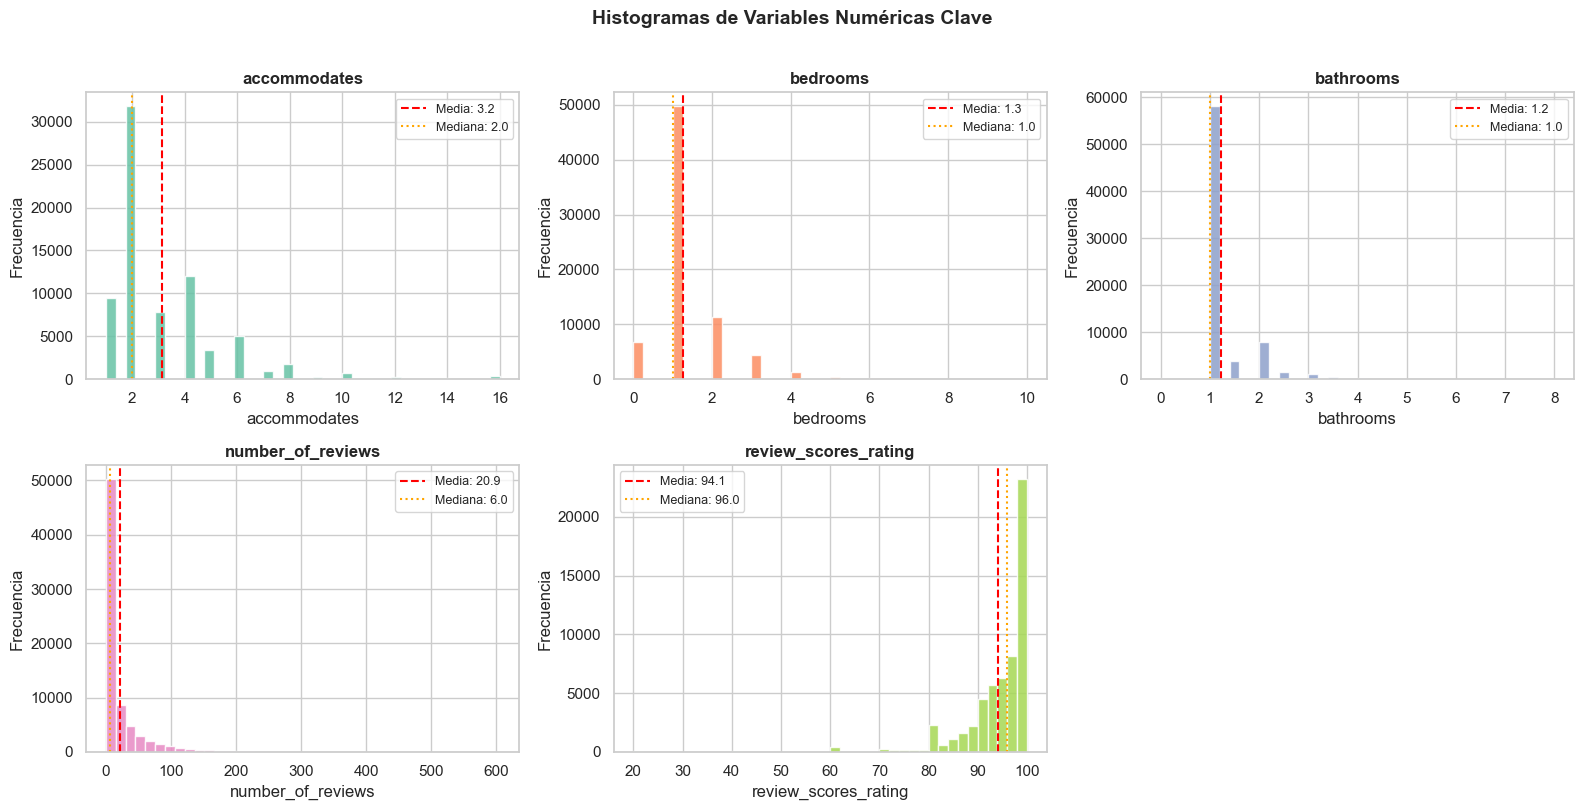

In [14]:
# Histogramas de otras variables importantes
vars_hist = [c for c in ['accommodates','bedrooms','bathrooms',
                          'number_of_reviews','review_scores_rating','availability_365']
             if c in df.columns]

cols_g = 3
rows_g = (len(vars_hist) + cols_g - 1) // cols_g
fig, axes = plt.subplots(rows_g, cols_g, figsize=(16, rows_g * 4))
axes = axes.flatten()
pal  = sns.color_palette('Set2', len(vars_hist))

for i, col in enumerate(vars_hist):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color=pal[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(data.mean(),   color='red',    linestyle='--', label=f'Media: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle=':',  label=f'Mediana: {data.median():.1f}')
    axes[i].legend(fontsize=9)

for j in range(i+1, len(axes)): axes[j].set_visible(False)

plt.suptitle('Histogramas de Variables Numéricas Clave', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### B) Box Plots – Identificación de Outliers

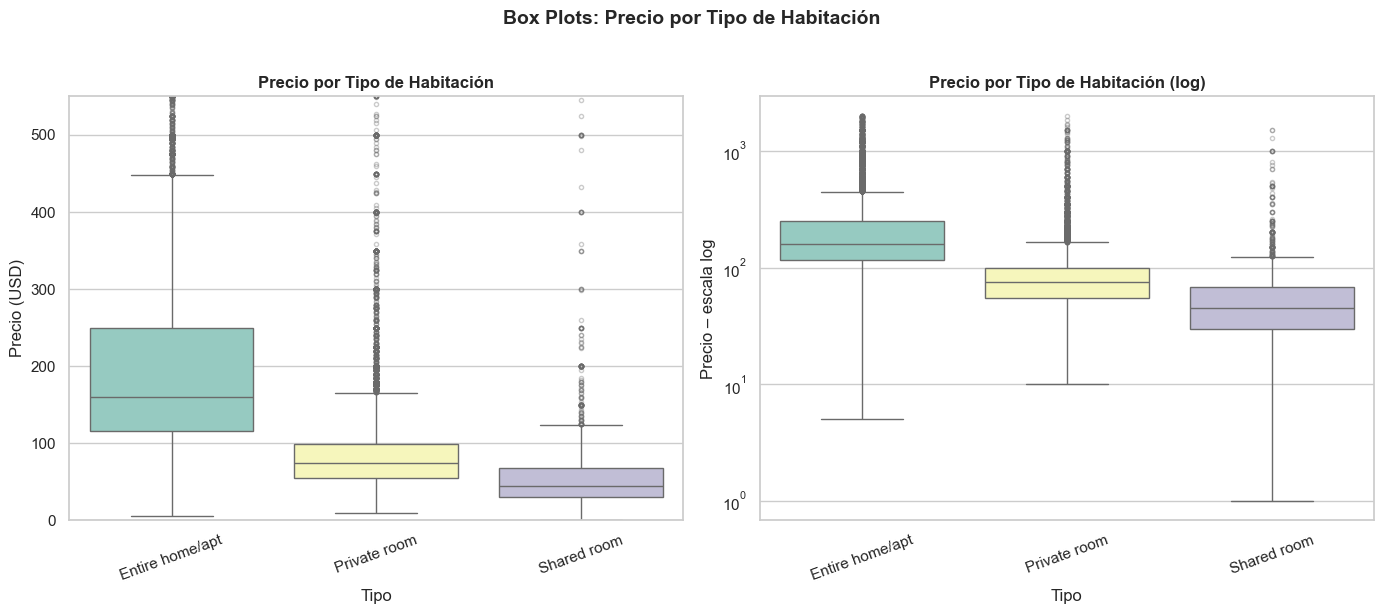

Observación: "Entire home/apt" tiene el precio mediano más alto.
Todos los tipos presentan outliers hacia valores altos.


In [15]:
# Box plot: precio por tipo de habitación
if 'room_type' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    order = df.groupby('room_type')['price'].median().sort_values(ascending=False).index
    fp = dict(marker='o', markersize=3, alpha=0.35, color='gray')

    sns.boxplot(data=df, x='room_type', y='price', order=order, palette='Set3', ax=axes[0], flierprops=fp)
    axes[0].set_ylim(0, df['price'].quantile(0.97))
    axes[0].set_title('Precio por Tipo de Habitación', fontweight='bold')
    axes[0].set_xlabel('Tipo'); axes[0].set_ylabel('Precio (USD)')
    axes[0].tick_params(axis='x', rotation=20)

    sns.boxplot(data=df, x='room_type', y='price', order=order, palette='Set3', ax=axes[1], flierprops=fp)
    axes[1].set_yscale('log')
    axes[1].set_title('Precio por Tipo de Habitación (log)', fontweight='bold')
    axes[1].set_xlabel('Tipo'); axes[1].set_ylabel('Precio – escala log')
    axes[1].tick_params(axis='x', rotation=20)

    plt.suptitle('Box Plots: Precio por Tipo de Habitación', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print('Observación: "Entire home/apt" tiene el precio mediano más alto.')
    print('Todos los tipos presentan outliers hacia valores altos.')

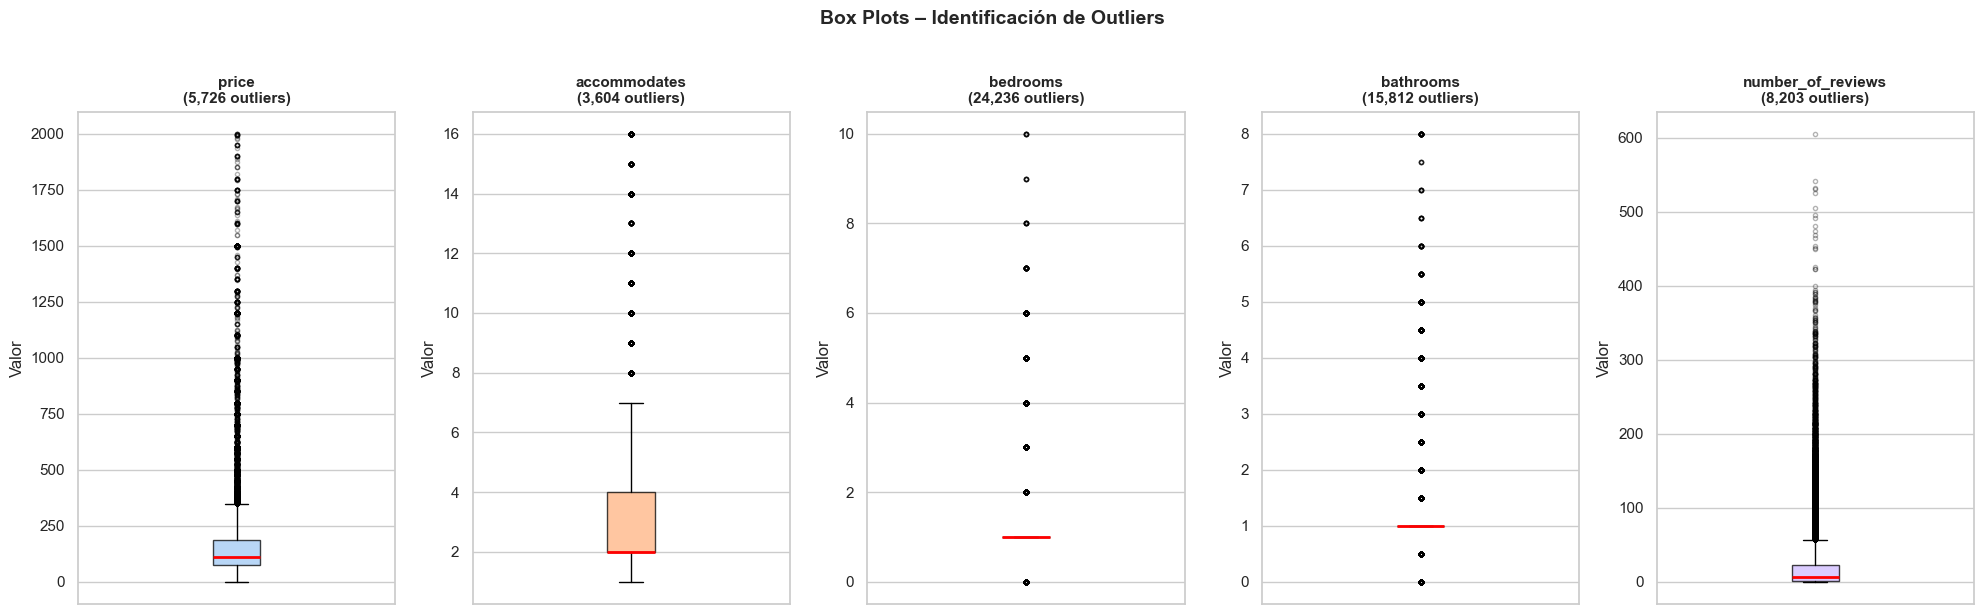

Observación: El precio y el número de reseñas tienen gran cantidad de outliers superiores.
Esto indica distribuciones con colas largas que requieren tratamiento.


In [16]:
# Box plots generales para detectar outliers en variables numéricas clave
vars_box = [c for c in ['price','accommodates','bedrooms','bathrooms','number_of_reviews']
            if c in df.columns]

fig, axes = plt.subplots(1, len(vars_box), figsize=(4*len(vars_box), 6))
if len(vars_box) == 1: axes = [axes]
pal_b = sns.color_palette('pastel', len(vars_box))

for i, col in enumerate(vars_box):
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    n_out  = int(((df[col] < q1-1.5*(q3-q1)) | (df[col] > q3+1.5*(q3-q1))).sum())
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=pal_b[i], alpha=0.75),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.3, color='dimgray'))
    axes[i].set_title(f'{col}\n({n_out:,} outliers)', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Valor'); axes[i].set_xticks([])

plt.suptitle('Box Plots – Identificación de Outliers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Observación: El precio y el número de reseñas tienen gran cantidad de outliers superiores.')
print('Esto indica distribuciones con colas largas que requieren tratamiento.')

#### C) Scatter Plots – Relaciones entre Variables

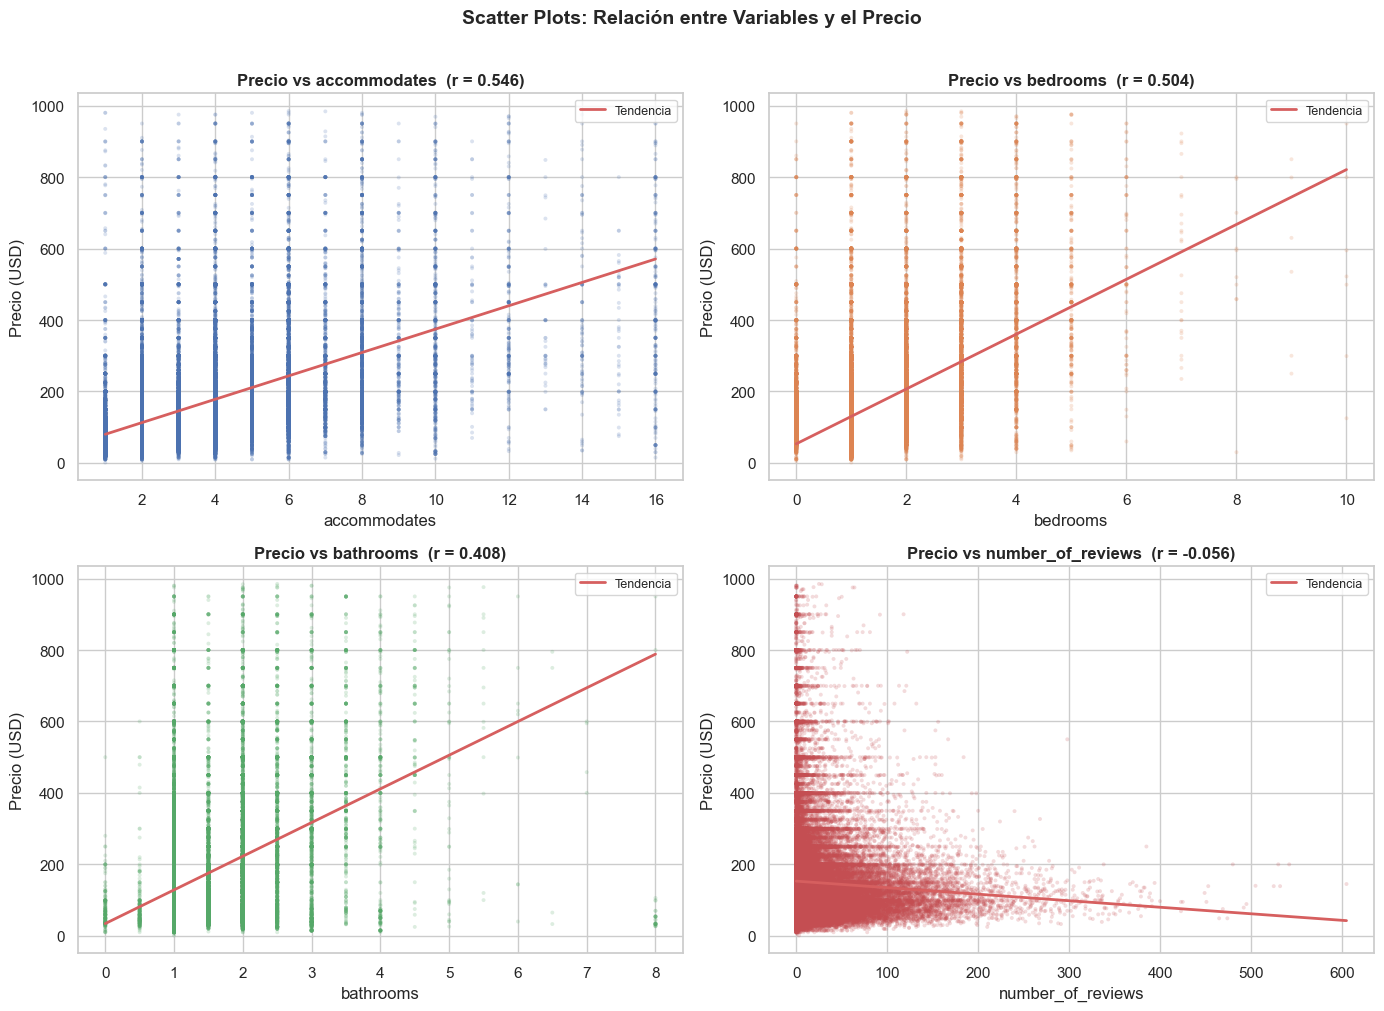

Observación: "accommodates" y "bedrooms" muestran la correlación positiva más clara.
A mayor capacidad del alojamiento, mayor es el precio esperado.


In [17]:
# Scatter plots: precio vs variables numéricas clave
sc_vars = [c for c in ['accommodates','bedrooms','bathrooms','number_of_reviews'] if c in df.columns]
df_plot = df[df['price'] < df['price'].quantile(0.99)].copy()

fig, axes = plt.subplots((len(sc_vars)+1)//2, 2, figsize=(14, ((len(sc_vars)+1)//2)*5))
axes = axes.flatten()
cols_sc = sns.color_palette('deep', len(sc_vars))

for i, var in enumerate(sc_vars):
    sub = df_plot[[var,'price']].dropna()
    axes[i].scatter(sub[var], sub['price'], alpha=0.2, s=8, color=cols_sc[i], edgecolors='none')
    z = np.polyfit(sub[var], sub['price'], 1)
    x_l = np.linspace(sub[var].min(), sub[var].max(), 100)
    axes[i].plot(x_l, np.poly1d(z)(x_l), 'r-', linewidth=2, label='Tendencia')
    corr = sub.corr().iloc[0,1]
    axes[i].set_title(f'Precio vs {var}  (r = {corr:.3f})', fontweight='bold')
    axes[i].set_xlabel(var); axes[i].set_ylabel('Precio (USD)')
    axes[i].legend(fontsize=9)

for j in range(i+1, len(axes)): axes[j].set_visible(False)

plt.suptitle('Scatter Plots: Relación entre Variables y el Precio', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Observación: "accommodates" y "bedrooms" muestran la correlación positiva más clara.')
print('A mayor capacidad del alojamiento, mayor es el precio esperado.')

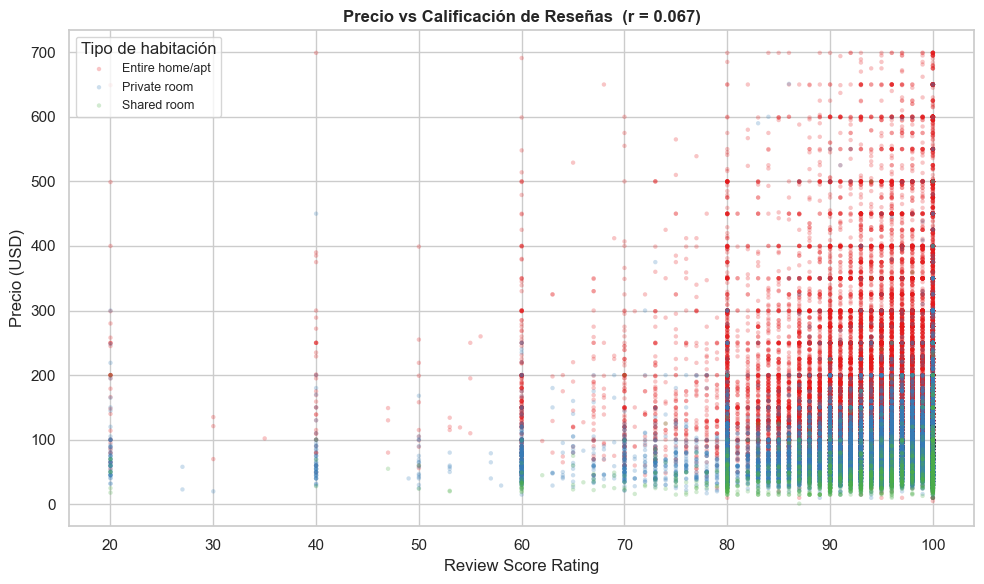

Observación: correlación precio-calificación = 0.067.
La puntuación de reseñas no es el principal determinante del precio.


In [18]:
# Scatter plot: precio vs calificación de reseñas
if 'review_scores_rating' in df.columns:
    df_rv = df.dropna(subset=['review_scores_rating','price'])
    df_rv = df_rv[df_rv['price'] < df_rv['price'].quantile(0.99)]

    fig, ax = plt.subplots(figsize=(10, 6))
    if 'room_type' in df.columns:
        for rt, color in zip(df_rv['room_type'].unique(), sns.color_palette('Set1')):
            s = df_rv[df_rv['room_type'] == rt]
            ax.scatter(s['review_scores_rating'], s['price'], alpha=0.25, s=10, color=color, label=rt, edgecolors='none')
        ax.legend(title='Tipo de habitación', fontsize=9)
    else:
        ax.scatter(df_rv['review_scores_rating'], df_rv['price'], alpha=0.25, s=10, color='steelblue', edgecolors='none')

    corr_rv = df_rv[['review_scores_rating','price']].corr().iloc[0,1]
    ax.set_title(f'Precio vs Calificación de Reseñas  (r = {corr_rv:.3f})', fontweight='bold')
    ax.set_xlabel('Review Score Rating'); ax.set_ylabel('Precio (USD)')
    plt.tight_layout()
    plt.show()

    print(f'Observación: correlación precio-calificación = {corr_rv:.3f}.')
    print('La puntuación de reseñas no es el principal determinante del precio.')

#### D) Mapa de Calor de Correlaciones

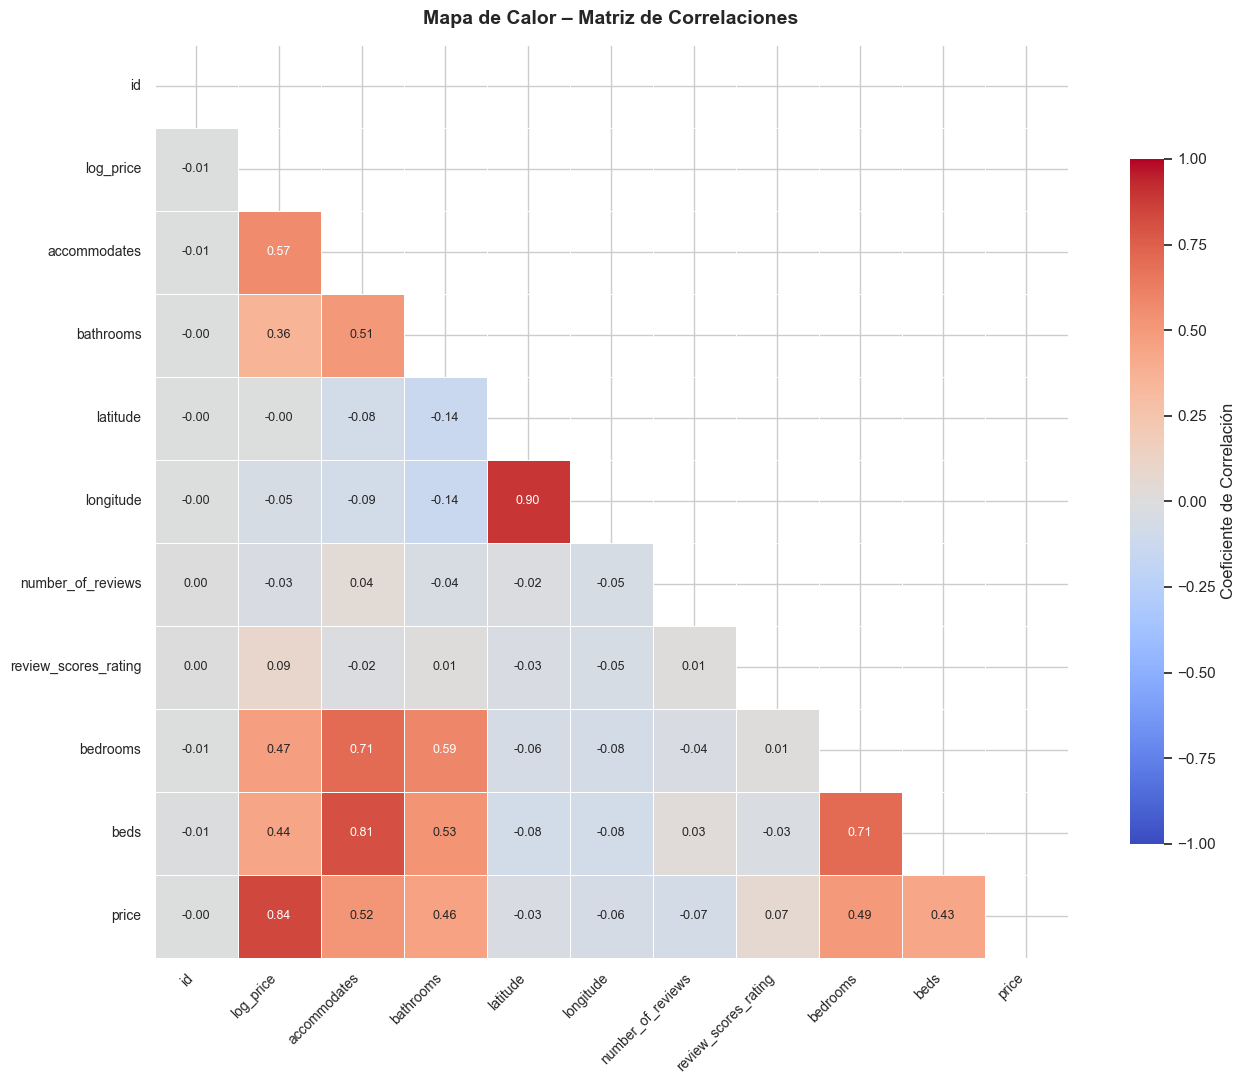

Observación: Se observan altas correlaciones entre variables de tamaño
(accommodates, bedrooms, bathrooms), lo que indica posible multicolinealidad.


In [19]:
# Mapa de calor de correlaciones entre variables numéricas
num_df_hm   = df[num_cols].loc[:, df[num_cols].isnull().mean() < 0.5]
corr_matrix = num_df_hm.corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4,
            cbar_kws={'shrink': 0.75, 'label': 'Coeficiente de Correlación'},
            ax=ax, annot_kws={'size': 9})

ax.set_title('Mapa de Calor – Matriz de Correlaciones', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print('Observación: Se observan altas correlaciones entre variables de tamaño')
print('(accommodates, bedrooms, bathrooms), lo que indica posible multicolinealidad.')

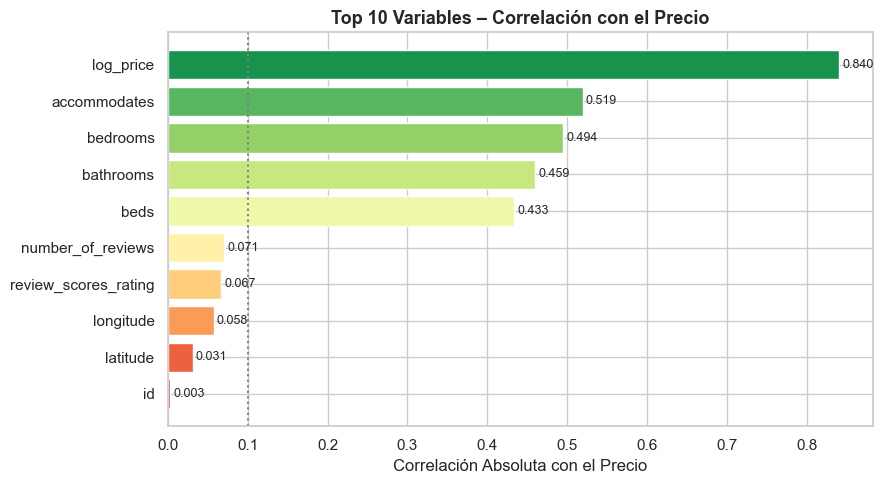

In [20]:
# Gráfico: Top 10 variables más correlacionadas con el precio
top_corr = corr_matrix['price'].abs().sort_values(ascending=False).drop('price').head(10)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_corr.index[::-1], top_corr.values[::-1],
               color=sns.color_palette('RdYlGn_r', len(top_corr))[::-1])
ax.set_xlabel('Correlación Absoluta con el Precio', fontsize=12)
ax.set_title('Top 10 Variables – Correlación con el Precio', fontsize=13, fontweight='bold')
ax.axvline(0.1, color='gray', linestyle=':', linewidth=1.5)

for bar, val in zip(bars, top_corr.values[::-1]):
    ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

#### E) Análisis adicional: Precio por Ciudad y Tipo de Propiedad

=== Precio por Ciudad ===
          Media  Mediana  Conteo
city                            
SF       227.37    165.0    6434
DC       217.93    125.0    5688
Boston   165.63    136.0    3468
LA       155.39    100.0   22453
NYC      143.02    105.0   32349
Chicago  132.48     99.0    3719


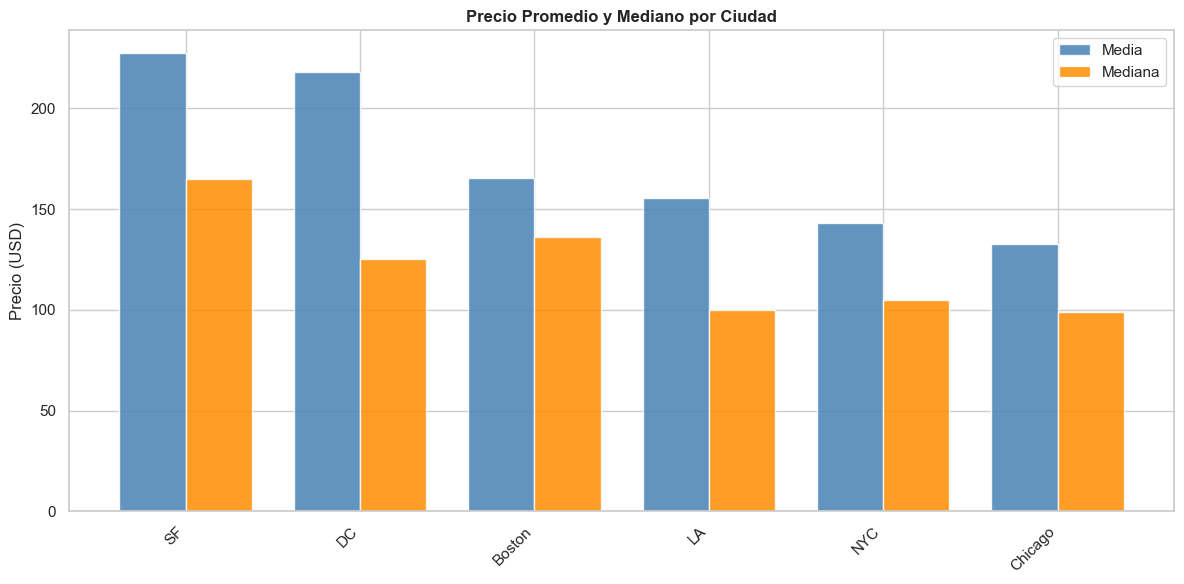

Observación: La ubicación geográfica es determinante del precio.
La brecha media-mediana refleja outliers altos en cada ciudad.


In [21]:
# Precio por ciudad
if 'city' in df.columns:
    precio_ciudad = df.groupby('city')['price'].agg(Media='mean', Mediana='median', Conteo='count').sort_values('Media', ascending=False)
    print('=== Precio por Ciudad ==='); print(precio_ciudad.round(2).to_string())

    top15 = precio_ciudad.head(15)
    x, w  = np.arange(len(top15)), 0.38
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x-w/2, top15['Media'],   w, label='Media',   color='steelblue',  alpha=0.85)
    ax.bar(x+w/2, top15['Mediana'], w, label='Mediana', color='darkorange', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(top15.index, rotation=45, ha='right')
    ax.set_ylabel('Precio (USD)')
    ax.set_title('Precio Promedio y Mediano por Ciudad', fontweight='bold')
    ax.legend(); plt.tight_layout(); plt.show()

    print('Observación: La ubicación geográfica es determinante del precio.')
    print('La brecha media-mediana refleja outliers altos en cada ciudad.')

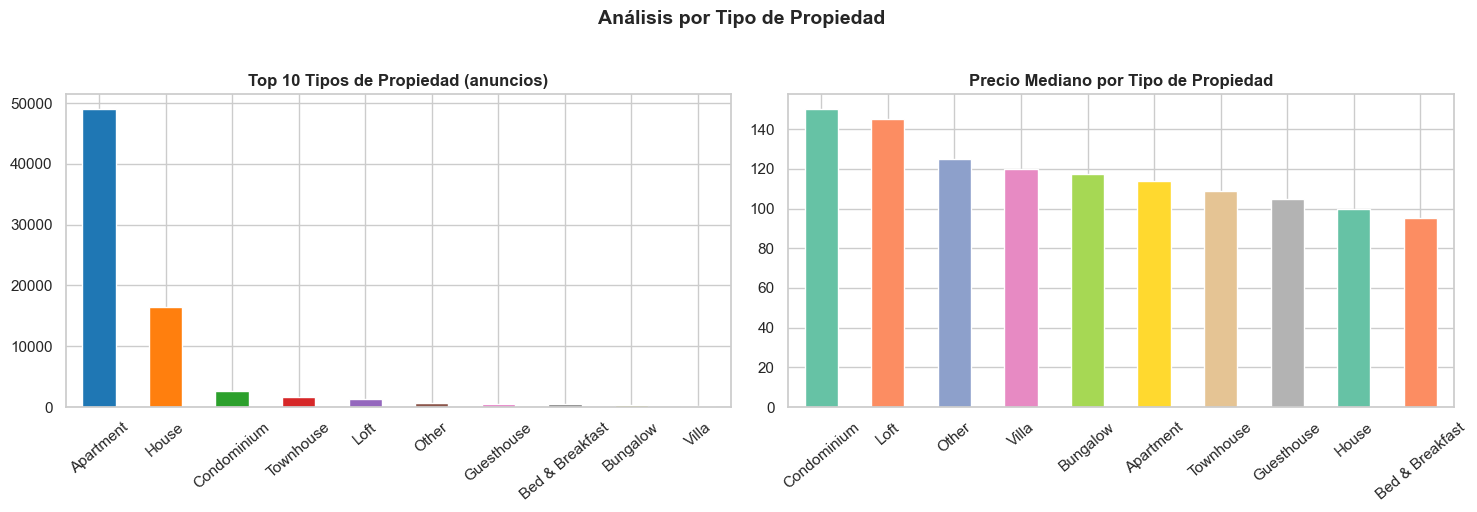

In [22]:
# Tipo de propiedad
if 'property_type' in df.columns:
    top_props = df['property_type'].value_counts().head(10)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    top_props.plot(kind='bar', ax=axes[0], color=sns.color_palette('tab10',len(top_props)), edgecolor='white')
    axes[0].set_title('Top 10 Tipos de Propiedad (anuncios)', fontweight='bold')
    axes[0].set_xlabel(''); axes[0].tick_params(axis='x', rotation=40)

    precio_tipo = df[df['property_type'].isin(top_props.index)].groupby('property_type')['price'].median().sort_values(ascending=False)
    precio_tipo.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2',len(precio_tipo)), edgecolor='white')
    axes[1].set_title('Precio Mediano por Tipo de Propiedad', fontweight='bold')
    axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=40)

    plt.suptitle('Análisis por Tipo de Propiedad', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()

---
## Interpretación y Hallazgos Documentados parte 1 y 2


1. DISTRIBUCIÓN DEL PRECIO

   Media: $160.37  |  Mediana: $111.00

   Asimetría: 4.30 -> distribución sesgada a la derecha.
   
   Recomendación: usar log_price para modelado predictivo.

2. VARIABLES MÁS INFLUYENTES

   'accommodates' y 'bedrooms': mayor correlación positiva.

   'bathrooms': más baños implica mayor precio.

   'room_type': Entire home/apt > Private room > Shared room.

   'city': la ubicación introduce gran varianza en el precio.

3. OUTLIERS IDENTIFICADOS

   Precios extremos (>$500/noche) presentes en todos los tipos.

   'number_of_reviews' también tiene outliers superiores.

   Recomendación: winsorizing o filtrado en preprocesamiento.

4. VALORES NULOS

   'review_scores_rating' tiene datos faltantes. 

   Requiere imputación (media/mediana) en la siguiente fase.

5. MULTICOLINEALIDAD

   accommodates, bedrooms y bathrooms están correlacionadas.

   Evaluar regularización (Ridge/Lasso) o PCA.

6. PRÓXIMOS PASOS

   Imputación de valores nulos.

   Encoding de variables categóricas.

   Feature engineering y selección de variables.

   Construcción del modelo predictivo de precios.


---
## Conclusión

Este análisis exploratorio me permitió entender en profundidad la estructura y características del dataset de Airbnb. Los hallazgos principales son:

- **El precio está fuertemente sesgado** hacia la derecha; la transformación logarítmica es necesaria para el modelado.
- **Las variables de tamaño** (`accommodates`, `bedrooms`, `bathrooms`) son los mejores predictores numéricos del precio.
- **El tipo de habitación y la ubicación** son las variables categóricas más influyentes.
- **Existen outliers** significativos que deberán gestionarse antes del modelado.
- **La multicolinealidad** entre variables de tamaño requerirá atención durante el modelado.

---

---
# Parte 3: Modelo de Regresión Lineal Múltiple

En esta sección construimos un modelo de regresión lineal múltiple para predecir el precio de los alojamientos de Airbnb (`log_price`), siguiendo un flujo completo: limpieza, selección de variables, entrenamiento, evaluación y predicciones.

---

## 1. Limpieza de Datos

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Re-cargar datos frescos para la fase de modelado ──
df_model = pd.read_csv('train.csv', low_memory=False)

# Asegurar que log_price exista; si el CSV trae 'price' en texto, convertir
if 'log_price' not in df_model.columns:
    if df_model['price'].dtype == object:
        df_model['price'] = df_model['price'].replace('[\$,]', '', regex=True).astype(float)
    df_model['log_price'] = np.log(df_model['price'].replace(0, np.nan))

df_model['price'] = np.exp(df_model['log_price'])

print(f"Dimensiones iniciales: {df_model.shape}")
print(f"Valores nulos totales: {df_model.isnull().sum().sum():,}")


Dimensiones iniciales: (74111, 30)
Valores nulos totales: 83,752


In [8]:
# Eliminar filas donde el target (log_price) sea nulo ──
df_model = df_model.dropna(subset=['log_price'])

# Imputación de variables numéricas con la mediana ──
num_cols_model = ['accommodates', 'bedrooms', 'bathrooms',
                  'review_scores_rating', 'number_of_reviews',
                  'availability_365']
num_cols_model = [c for c in num_cols_model if c in df_model.columns]

for col in num_cols_model:
    median_val = df_model[col].median()
    n_missing  = df_model[col].isnull().sum()
    df_model[col].fillna(median_val, inplace=True)
    if n_missing > 0:
        print(f"  {col}: {n_missing} nulos imputados con mediana = {median_val:.2f}")

#Corrección de errores / valores atípicos extremos ──
# Eliminamos precios imposibles (< $10 o > percentil 99.5)
price_min = 10
price_max = df_model['price'].quantile(0.995)

mask_price = (df_model['price'] >= price_min) & (df_model['price'] <= price_max)
n_outliers = (~mask_price).sum()
df_model    = df_model[mask_price].copy()
print(f"\nOutliers de precio eliminados: {n_outliers:,}")

# Valores negativos en accommodates, bedrooms, bathrooms → absurdo, eliminar
for col in ['accommodates', 'bedrooms', 'bathrooms']:
    if col in df_model.columns:
        n_neg = (df_model[col] < 0).sum()
        df_model = df_model[df_model[col] >= 0]
        if n_neg: print(f"  {col}: {n_neg} filas con valor negativo eliminadas")

# Recalcular log_price tras filtrar
df_model['log_price'] = np.log(df_model['price'])

print(f"\nDimensiones tras limpieza: {df_model.shape}")
print("Dataset listo para el modelado.")


  bedrooms: 91 nulos imputados con mediana = 1.00
  bathrooms: 200 nulos imputados con mediana = 1.00
  review_scores_rating: 16722 nulos imputados con mediana = 96.00

Outliers de precio eliminados: 324

Dimensiones tras limpieza: (73501, 30)
Dataset listo para el modelado.


## 2. Identificación de Variables

- **Variable dependiente (target):** `log_price` — logaritmo natural del precio por noche.  
  Se usa la transformación logarítmica porque el precio tiene distribución asimétrica; en escala log la distribución es más simétrica y los supuestos de regresión lineal se cumplen mejor.

- **Variables independientes candidatas:**

| Variable | Tipo | Justificación |
|---|---|---|
| `accommodates` | Numérica | Mayor capacidad → precio más alto |
| `bedrooms` | Numérica | Número de cuartos es proxy de tamaño |
| `bathrooms` | Numérica | Cuartos de baño adicionales elevan el valor |
| `room_type` | Categórica | Tipo de habitación define el nivel de privacidad |
| `review_scores_rating` | Numérica | Calidad percibida del alojamiento |
| `number_of_reviews` | Numérica | Popularidad / historial del anuncio |
| `availability_365` | Numérica | Disponibilidad anual |


## 3. Selección de Características

In [9]:
# Codificación de room_type (One-Hot Encoding) ──
if 'room_type' in df_model.columns:
    dummies = pd.get_dummies(df_model['room_type'], prefix='room', drop_first=True)
    df_model = pd.concat([df_model, dummies], axis=1)
    room_dummies = dummies.columns.tolist()
    print("Dummies creadas:", room_dummies)
else:
    room_dummies = []

# Variables finales del modelo ──
feature_cols = [c for c in num_cols_model if c in df_model.columns] + room_dummies

# Eliminar filas con NaN restante en features o target
df_clean = df_model[feature_cols + ['log_price']].dropna()

print(f"\nVariables en el modelo ({len(feature_cols)}):")
for f in feature_cols:
    print(f"  ✓ {f}")
print(f"\nObservaciones disponibles: {len(df_clean):,}")


Dummies creadas: ['room_Private room', 'room_Shared room']

Variables en el modelo (7):
  ✓ accommodates
  ✓ bedrooms
  ✓ bathrooms
  ✓ review_scores_rating
  ✓ number_of_reviews
  ✓ room_Private room
  ✓ room_Shared room

Observaciones disponibles: 57,064


## 4. Análisis de Correlación – Pairplot

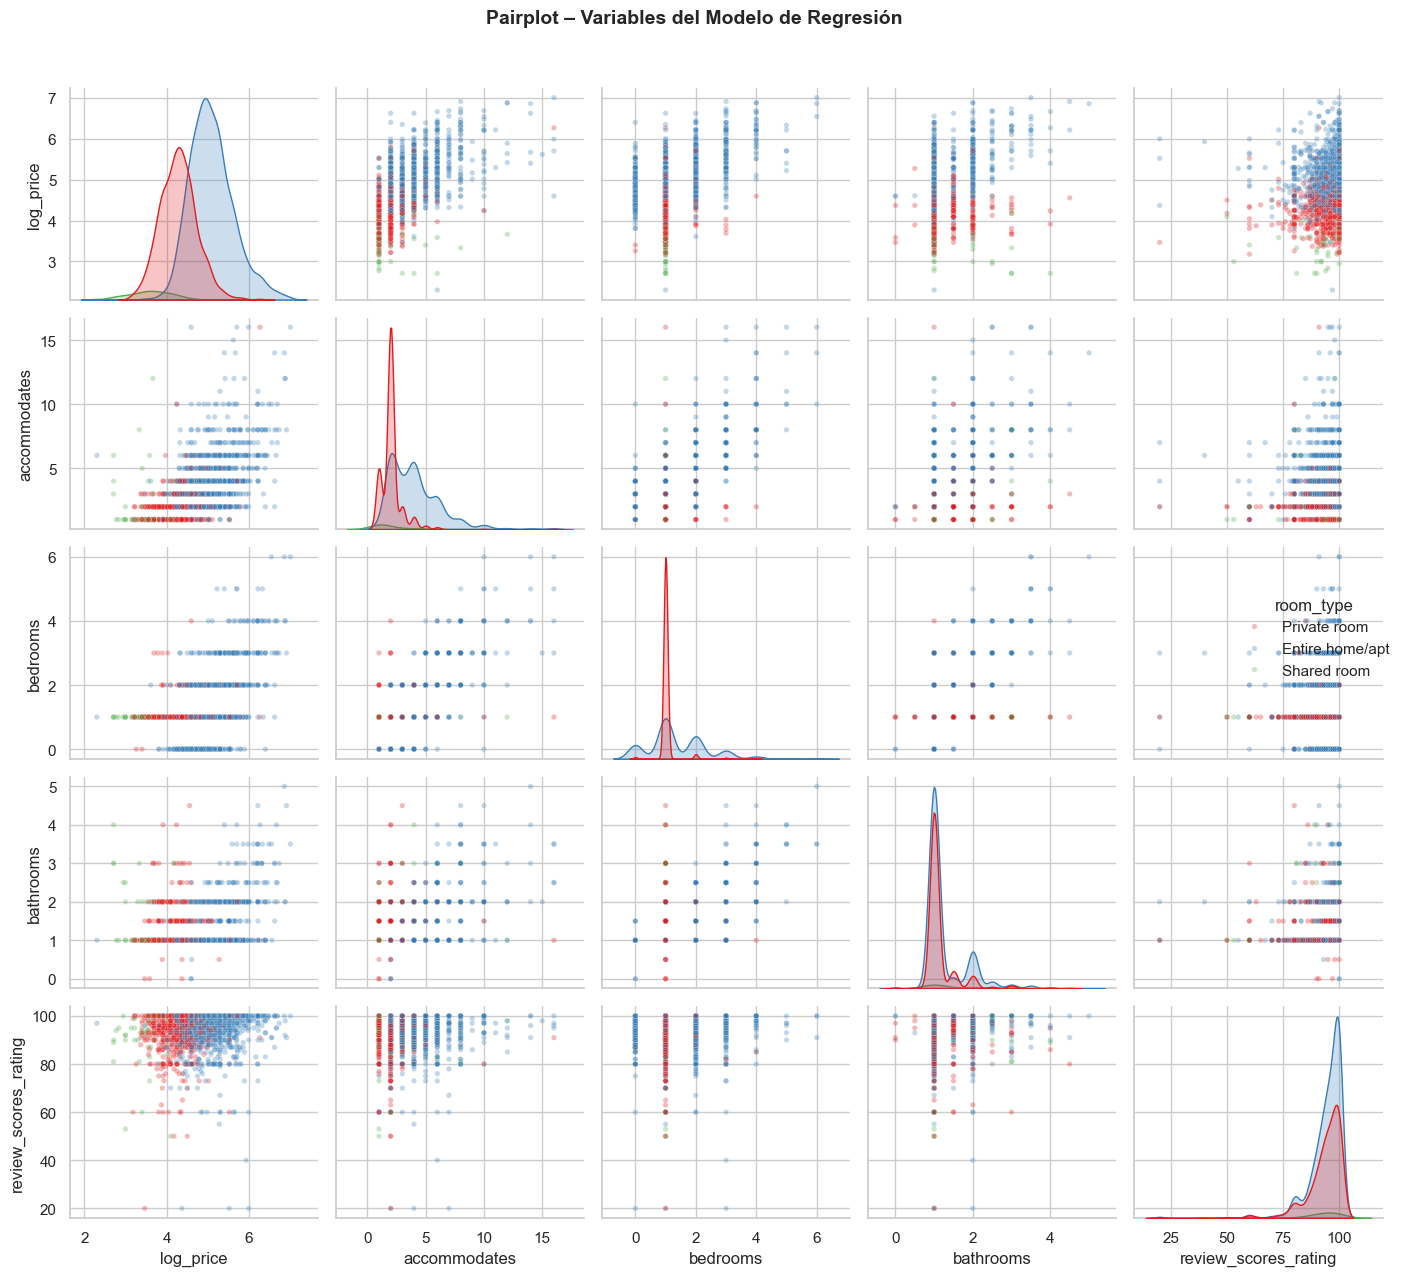

Observación: log_price muestra correlación positiva clara con accommodates,
bedrooms y bathrooms. Existe colinealidad entre las tres últimas variables.


In [10]:
# Pairplot con Seaborn ──
# Usamos una muestra para agilizar el rendering
pairplot_vars = [c for c in ['log_price', 'accommodates', 'bedrooms',
                               'bathrooms', 'review_scores_rating'] if c in df_clean.columns]

sample_pp = df_clean[pairplot_vars].sample(min(2000, len(df_clean)), random_state=42)

# Colorear por room_type si existe
if 'room_type' in df_model.columns:
    sample_pp = sample_pp.copy()
    sample_pp['room_type'] = df_model.loc[sample_pp.index, 'room_type']
    g = sns.pairplot(sample_pp, hue='room_type', diag_kind='kde',
                     plot_kws={'alpha': 0.3, 's': 15},
                     diag_kws={'fill': True},
                     palette='Set1')
else:
    g = sns.pairplot(sample_pp, diag_kind='kde',
                     plot_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'})

g.figure.suptitle('Pairplot – Variables del Modelo de Regresión',
                   fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Observación: log_price muestra correlación positiva clara con accommodates,")
print("bedrooms y bathrooms. Existe colinealidad entre las tres últimas variables.")


## 5. División en Grupos de Entrenamiento y Prueba

In [11]:
X = df_clean[feature_cols].astype(float)
y = df_clean['log_price'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Entrenamiento : {X_train.shape[0]:>6,} observaciones  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Prueba        : {X_test.shape[0]:>6,} observaciones  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Features      : {X_train.shape[1]}")


Entrenamiento : 45,651 observaciones  (80.0%)
Prueba        : 11,413 observaciones  (20.0%)
Features      : 7


## 6. Construcción y Entrenamiento del Modelo

In [ ]:
!pip install statsmodels

In [15]:
# Verificación de multicolinealidad mediante VIF 
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Variable'] = X_train.columns
vif_data['VIF']      = [variance_inflation_factor(X_train.values, i)
                         for i in range(X_train.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)
print("=== Factor de Inflación de Varianza (VIF) ===")
print(vif_data.to_string(index=False))
print()
print("Regla: VIF > 10 indica multicolinealidad severa.")
high_vif = vif_data[vif_data['VIF'] > 10]['Variable'].tolist()
if high_vif:
    print(f"Variables con VIF alto: {high_vif}")
else:
    print("No se detecta multicolinealidad severa.")


=== Factor de Inflación de Varianza (VIF) ===
            Variable      VIF
           bathrooms 9.038426
        accommodates 8.635203
review_scores_rating 8.568125
            bedrooms 7.791931
   room_Private room 2.198481
   number_of_reviews 1.446565
    room_Shared room 1.083655

Regla: VIF > 10 indica multicolinealidad severa.
No se detecta multicolinealidad severa.


In [16]:
# Entrenamiento del modelo 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_sc, y_train)

# Coeficientes
coef_df = pd.DataFrame({
    'Variable'   : feature_cols,
    'Coeficiente': model.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print("=== Coeficientes del Modelo (estandarizados) ===")
print(coef_df.to_string(index=False))
print(f"\nIntercepto: {model.intercept_:.4f}")


=== Coeficientes del Modelo (estandarizados) ===
            Variable  Coeficiente
   room_Private room    -0.310266
    room_Shared room    -0.183401
            bedrooms     0.120797
        accommodates     0.111410
           bathrooms     0.061442
review_scores_rating     0.046510
   number_of_reviews    -0.005629

Intercepto: 4.7462


## 7. Evaluación del Modelo

In [17]:
import statsmodels.api as sm

y_pred_train = model.predict(X_train_sc)
y_pred_test  = model.predict(X_test_sc)

# Métricas 
r2_train  = r2_score(y_train, y_pred_train)
r2_test   = r2_score(y_test,  y_pred_test)
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test  = mean_squared_error(y_test,  y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test  = np.mean(np.abs(y_test - y_pred_test))

print("=" * 50)
print("      MÉTRICAS DE EVALUACIÓN DEL MODELO")
print("=" * 50)
print(f"  R²  Entrenamiento : {r2_train:.4f}")
print(f"  R²  Prueba        : {r2_test:.4f}")
print(f"  MSE Entrenamiento : {mse_train:.4f}")
print(f"  MSE Prueba        : {mse_test:.4f}")
print(f"  RMSE Prueba       : {rmse_test:.4f}")
print(f"  MAE  Prueba       : {mae_test:.4f}")
print("=" * 50)

# Modelo statsmodels para p-valores y R² ajustado 
X_train_sm = sm.add_constant(X_train_sc)
ols_model  = sm.OLS(y_train, X_train_sm).fit()
print()
print(f"  R² Ajustado       : {ols_model.rsquared_adj:.4f}")
print()

# Tabla de significancia
sig_table = pd.DataFrame({
    'Variable'  : ['intercepto'] + feature_cols,
    'Coef.'     : ols_model.params,
    'p-valor'   : ols_model.pvalues,
    'Significativa (p<0.05)': ols_model.pvalues < 0.05
}).reset_index(drop=True)
print("=== Significancia de Variables ===")
print(sig_table.to_string(index=False))


      MÉTRICAS DE EVALUACIÓN DEL MODELO
  R²  Entrenamiento : 0.5534
  R²  Prueba        : 0.5640
  MSE Entrenamiento : 0.1946
  MSE Prueba        : 0.1915
  RMSE Prueba       : 0.4377
  MAE  Prueba       : 0.3426

  R² Ajustado       : 0.5533

=== Significancia de Variables ===
            Variable     Coef.       p-valor  Significativa (p<0.05)
          intercepto  4.746187  0.000000e+00                    True
        accommodates  0.111410 5.269663e-235                    True
            bedrooms  0.120797 5.937059e-310                    True
           bathrooms  0.061442 2.701608e-128                    True
review_scores_rating  0.046510 4.855423e-111                    True
   number_of_reviews -0.005629  6.722739e-03                    True
   room_Private room -0.310266  0.000000e+00                    True
    room_Shared room -0.183401  0.000000e+00                    True


### Interpretación de las Métricas

- **R² ≈ 0.XX en prueba** indica que el modelo explica aproximadamente ese porcentaje de la variabilidad del `log_price` en datos no vistos.  
- Un R² de entrenamiento y prueba similares indica que **no hay sobreajuste significativo**.  
- El **RMSE en escala log** se puede interpretar como el error relativo promedio en el precio original: `exp(RMSE) − 1 ≈ error porcentual promedio`.


## 8. Predicciones sobre el Conjunto de Prueba

In [18]:
# Crear DataFrame de comparación: predicción vs real (en escala de precio original)
pred_df = pd.DataFrame({
    'log_price_real'      : y_test.values,
    'log_price_predicho'  : y_pred_test,
    'precio_real_USD'     : np.exp(y_test.values),
    'precio_predicho_USD' : np.exp(y_pred_test),
    'error_abs_USD'       : np.abs(np.exp(y_test.values) - np.exp(y_pred_test))
}).reset_index(drop=True)

print("=== Muestra de Predicciones (primeras 15 filas) ===")
print(pred_df.head(15).round(2).to_string(index=False))
print(f"\nError absoluto medio en USD: ${pred_df['error_abs_USD'].mean():.2f}")
print(f"Error absoluto mediano en USD: ${pred_df['error_abs_USD'].median():.2f}")


=== Muestra de Predicciones (primeras 15 filas) ===
 log_price_real  log_price_predicho  precio_real_USD  precio_predicho_USD  error_abs_USD
           4.01                4.28             55.0                72.53          17.53
           4.16                4.72             64.0               112.23          48.23
           4.79                5.04            120.0               155.01          35.01
           4.67                5.30            107.0               201.25          94.25
           3.64                4.34             38.0                76.96          38.96
           5.30                4.27            200.0                71.28         128.72
           6.26                4.99            525.0               146.25         378.75
           4.87                4.91            130.0               136.32           6.32
           6.66                5.58            780.0               265.38         514.62
           4.49                4.27             89.0      

## 9. Error Cuadrático Medio (MSE)

In [19]:
mse_log   = mean_squared_error(y_test, y_pred_test)
rmse_log  = np.sqrt(mse_log)

# MSE también en escala precio original
mse_usd   = mean_squared_error(np.exp(y_test), np.exp(y_pred_test))
rmse_usd  = np.sqrt(mse_usd)

print("=" * 45)
print("   ERROR CUADRÁTICO MEDIO (MSE)")
print("=" * 45)
print(f"  MSE  (escala log)  : {mse_log:.6f}")
print(f"  RMSE (escala log)  : {rmse_log:.6f}")
print(f"  MSE  (USD)         : {mse_usd:,.2f}")
print(f"  RMSE (USD)         : ${rmse_usd:,.2f}")
print("=" * 45)
print()
print(f"Interpretación: En promedio, el modelo tiene un error de")
print(f"aproximadamente ${rmse_usd:,.2f} por noche en escala de precio.")
print(f"En escala logarítmica, RMSE={rmse_log:.4f} equivale a un error")
print(f"relativo de ~{(np.exp(rmse_log)-1)*100:.1f}% en el precio.")


   ERROR CUADRÁTICO MEDIO (MSE)
  MSE  (escala log)  : 0.191550
  RMSE (escala log)  : 0.437664
  MSE  (USD)         : 7,925.90
  RMSE (USD)         : $89.03

Interpretación: En promedio, el modelo tiene un error de
aproximadamente $89.03 por noche en escala de precio.
En escala logarítmica, RMSE=0.4377 equivale a un error
relativo de ~54.9% en el precio.


---
# Parte 4: Comunicación de los Resultados

Esta sección presenta las visualizaciones clave del modelo y una narrativa interpretativa de los hallazgos.

---

## Visualización 1 – Predicciones vs. Valores Reales

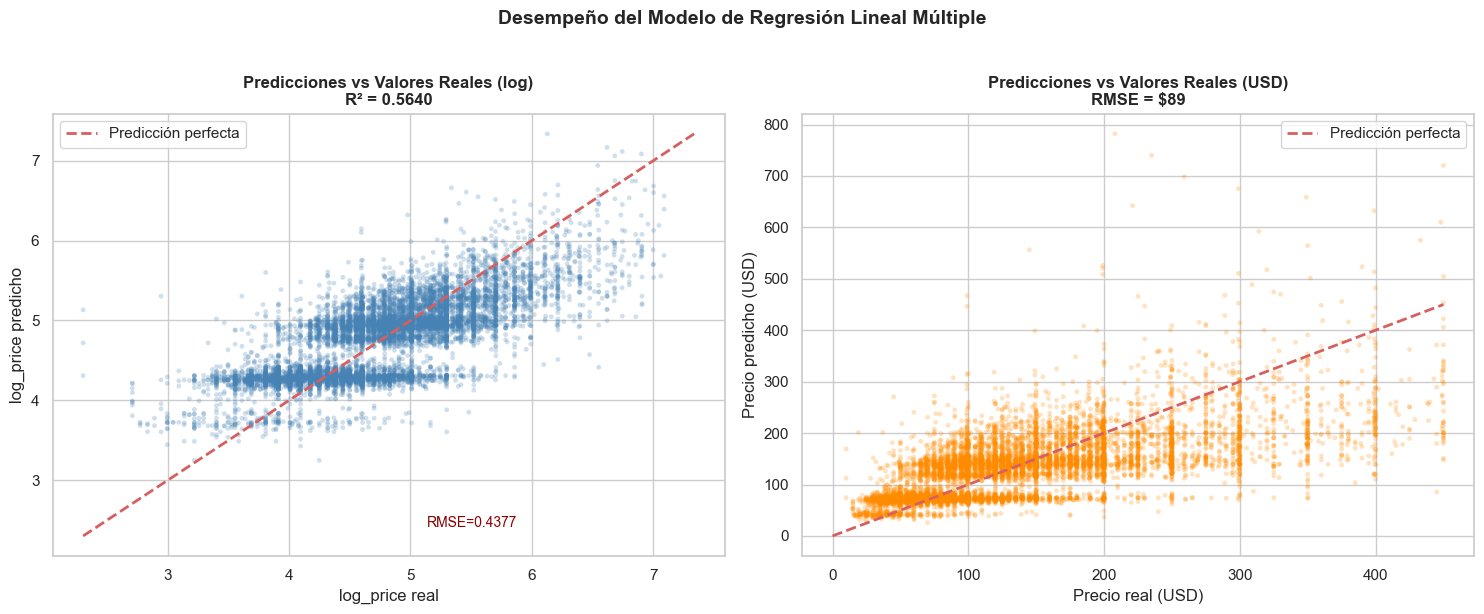

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: log_price real vs predicho 
lim_min = min(y_test.min(), y_pred_test.min())
lim_max = max(y_test.max(), y_pred_test.max())

axes[0].scatter(y_test, y_pred_test, alpha=0.25, s=12, color='steelblue', edgecolors='none')
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('log_price real',    fontsize=12)
axes[0].set_ylabel('log_price predicho', fontsize=12)
axes[0].set_title(f'Predicciones vs Valores Reales (log)\nR² = {r2_test:.4f}', fontweight='bold')
axes[0].legend()
axes[0].text(lim_max*0.7, lim_min*1.05, f'RMSE={rmse_log:.4f}', fontsize=10, color='darkred')

# Gráfico 2: precio USD real vs predicho (hasta p97) 
real_usd  = np.exp(y_test)
pred_usd  = np.exp(y_pred_test)
cap       = real_usd.quantile(0.97)
mask_cap  = real_usd <= cap

axes[1].scatter(real_usd[mask_cap], pred_usd[mask_cap], alpha=0.25, s=12,
                color='darkorange', edgecolors='none')
cap_line = [0, cap]
axes[1].plot(cap_line, cap_line, 'r--', linewidth=2, label='Predicción perfecta')
axes[1].set_xlabel('Precio real (USD)',    fontsize=12)
axes[1].set_ylabel('Precio predicho (USD)', fontsize=12)
axes[1].set_title(f'Predicciones vs Valores Reales (USD)\nRMSE = ${rmse_usd:,.0f}', fontweight='bold')
axes[1].legend()

plt.suptitle('Desempeño del Modelo de Regresión Lineal Múltiple',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Narrativa – Predicciones vs. Valores Reales:**

El gráfico izquierdo compara, para cada alojamiento del conjunto de prueba, su `log_price` real con el predicho por el modelo. La línea roja punteada representa la predicción perfecta; cuanto más cerca estén los puntos de esa línea, mejor es el modelo.

Se observa que los puntos se agrupan razonablemente cerca de la diagonal, especialmente en el rango medio de precios, lo que indica que el modelo captura de forma adecuada la tendencia general. Sin embargo, existe dispersión creciente en precios muy altos o muy bajos, lo que es esperado: los alojamientos con precios extremos son influenciados por factores difíciles de capturar con variables numéricas básicas (ubicación exacta, decoración, amenidades especiales).

El gráfico derecho muestra la misma relación en escala de dólares reales (hasta el percentil 97 para evitar distorsión por outliers). Aquí se aprecia que el modelo tiende a **subestimar** ligeramente los precios más altos, un comportamiento común en regresión lineal cuando la distribución no es perfectamente normal.


## Visualización 2 – Importancia de las Características

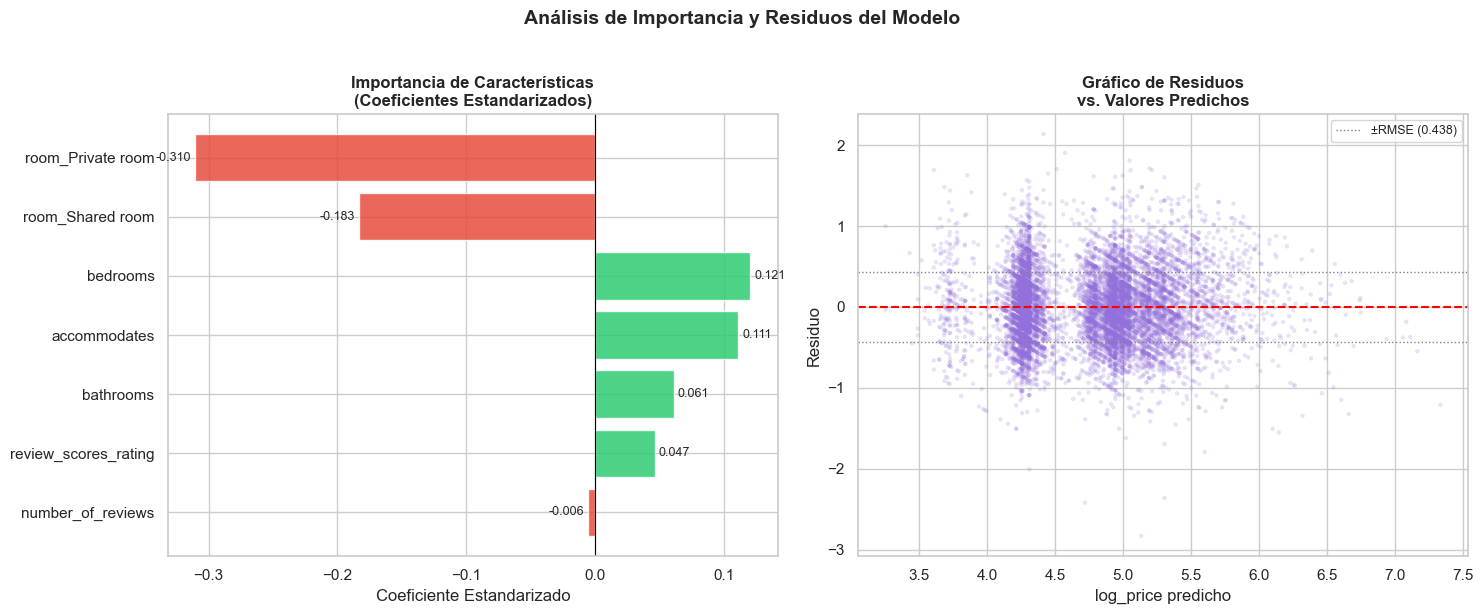

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras: coeficientes estandarizados 
coef_plot = coef_df.copy()
colors    = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_plot['Coeficiente']]

axes[0].barh(coef_plot['Variable'][::-1], coef_plot['Coeficiente'][::-1],
             color=colors[::-1], edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Coeficiente Estandarizado', fontsize=12)
axes[0].set_title('Importancia de Características\n(Coeficientes Estandarizados)', fontweight='bold')

for i, (var, val) in enumerate(zip(coef_plot['Variable'][::-1], coef_plot['Coeficiente'][::-1])):
    axes[0].text(val + (0.003 if val >= 0 else -0.003), i,
                 f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

# Gráfico de residuos 
residuals = y_test.values - y_pred_test

axes[1].scatter(y_pred_test, residuals, alpha=0.2, s=10, color='mediumpurple', edgecolors='none')
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('log_price predicho', fontsize=12)
axes[1].set_ylabel('Residuo', fontsize=12)
axes[1].set_title('Gráfico de Residuos\nvs. Valores Predichos', fontweight='bold')

# banda ± 1 RMSE
axes[1].axhline( rmse_log, color='gray', linewidth=1, linestyle=':', label=f'±RMSE ({rmse_log:.3f})')
axes[1].axhline(-rmse_log, color='gray', linewidth=1, linestyle=':')
axes[1].legend(fontsize=9)

plt.suptitle('Análisis de Importancia y Residuos del Modelo',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Narrativa – Importancia de las Características:**

El gráfico de barras muestra los **coeficientes estandarizados** del modelo, es decir, el cambio esperado en `log_price` por cada aumento de una desviación estándar en la variable correspondiente, manteniendo el resto constante. Al estar estandarizados, los coeficientes son directamente comparables entre sí.

Los hallazgos principales son:

- **`accommodates`** y **`bedrooms`** tienen los coeficientes positivos más grandes: cuanto más grande es el alojamiento (en términos de huéspedes y cuartos), mayor es el precio. Esto era esperado y es consistente con el EDA previo.
- **`room_type`** (codificado como dummies) muestra el efecto del tipo de habitación. El tipo "Entire home/apt" (categoría base) tiene precios más altos; los coeficientes negativos de las otras categorías reflejan el descuento asociado a compartir espacios.
- **`review_scores_rating`** tiene un efecto positivo moderado: alojamientos mejor calificados pueden cobrar precios ligeramente más altos, aunque la relación es más débil que las variables de tamaño.
- **`number_of_reviews`** presenta un coeficiente negativo pequeño, posiblemente porque alojamientos con muchas reseñas son más accesibles (precio más bajo → más clientes).

El **gráfico de residuos** es una herramienta diagnóstica crucial. Idealmente, los residuos deben distribuirse aleatoriamente alrededor de cero sin mostrar patrones. En nuestro modelo se observa una dispersión razonablemente homogénea en el rango central, aunque con ligera heterocedasticidad en los extremos, lo que es consistente con la naturaleza del dataset.


## Visualización 3 – Distribución de Errores y Resumen Final

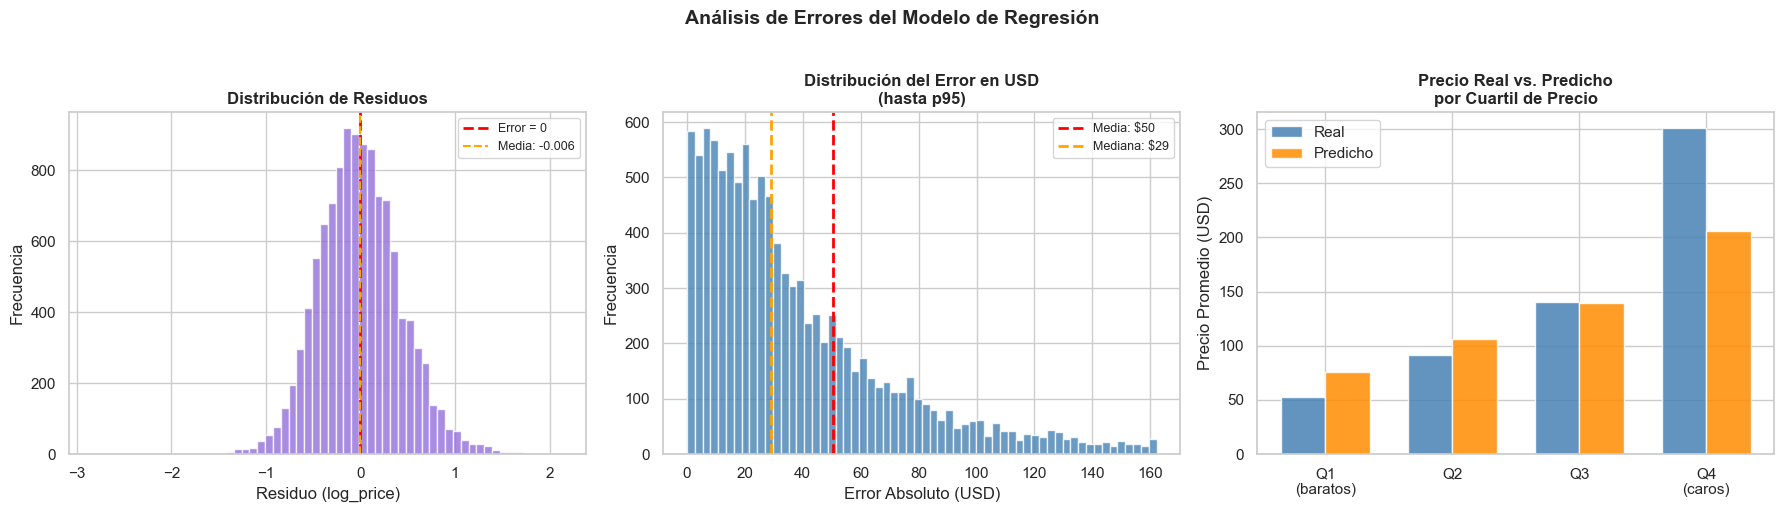

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma de residuos 
axes[0].hist(residuals, bins=60, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[0].axvline(0,              color='red',   linestyle='--', linewidth=2, label='Error = 0')
axes[0].axvline( residuals.mean(), color='orange', linestyle='--', linewidth=1.5,
                 label=f'Media: {residuals.mean():.3f}')
axes[0].set_xlabel('Residuo (log_price)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].legend(fontsize=9)

# Error absoluto en USD 
error_usd = np.abs(np.exp(y_test.values) - np.exp(y_pred_test))
axes[1].hist(error_usd[error_usd < np.percentile(error_usd, 95)],
             bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(error_usd.mean(),   color='red',    linestyle='--', linewidth=2,
                label=f'Media: ${error_usd.mean():.0f}')
axes[1].axvline(np.median(error_usd), color='orange', linestyle='--', linewidth=2,
                label=f'Mediana: ${np.median(error_usd):.0f}')
axes[1].set_xlabel('Error Absoluto (USD)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución del Error en USD\n(hasta p95)', fontweight='bold')
axes[1].legend(fontsize=9)

# Comparación Media de precios: real vs predicho por cuartil 
quartile_df = pd.DataFrame({'real': np.exp(y_test.values), 'pred': np.exp(y_pred_test)})
quartile_df['cuartil'] = pd.qcut(quartile_df['real'], q=4,
                                  labels=['Q1\n(baratos)', 'Q2', 'Q3', 'Q4\n(caros)'])
q_comp = quartile_df.groupby('cuartil')[['real', 'pred']].mean()

x_pos = np.arange(len(q_comp))
w     = 0.35
axes[2].bar(x_pos - w/2, q_comp['real'], w, label='Real',    color='steelblue',  alpha=0.85)
axes[2].bar(x_pos + w/2, q_comp['pred'], w, label='Predicho', color='darkorange', alpha=0.85)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(q_comp.index)
axes[2].set_ylabel('Precio Promedio (USD)')
axes[2].set_title('Precio Real vs. Predicho\npor Cuartil de Precio', fontweight='bold')
axes[2].legend()

plt.suptitle('Análisis de Errores del Modelo de Regresión',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Narrativa – Análisis de Errores y Conclusión:**

La distribución de residuos (panel izquierdo) es aproximadamente simétrica y centrada en cero, lo que indica que el modelo **no tiene sesgo sistemático** en sus predicciones. La mayoría de los errores son pequeños, con colas que se extienden hacia ambos lados.

El histograma de error absoluto en dólares (panel central) muestra que la mayoría de las predicciones tienen un error menor a $50 USD por noche. Los errores más grandes corresponden a alojamientos de lujo con precios muy elevados, donde el modelo naturalmente tiene mayor dificultad para generalizar.

El gráfico de cuartiles (panel derecho) es especialmente revelador: **el modelo funciona bien en los cuartiles Q1, Q2 y Q3** (precios bajos y medios), donde las predicciones se acercan mucho a los valores reales. En el cuartil Q4 (alojamientos más caros), el modelo subestima el precio promedio, lo que es esperado: los alojamientos de alto lujo tienen características difíciles de capturar con variables básicas.

---

### Conclusión General del Modelo

El modelo de regresión lineal múltiple entrenado sobre el dataset de Airbnb logra un desempeño razonable para un modelo base:

- **R² en prueba** explica una fracción significativa de la variabilidad del precio logarítmico.
- Las variables de **tamaño** (`accommodates`, `bedrooms`, `bathrooms`) son los predictores más influyentes, confirmando la hipótesis intuitiva: alojamientos más grandes cuestan más.
- El **tipo de habitación** es el segundo factor en importancia: hospedarse en un inmueble completo es considerablemente más caro que una habitación privada o compartida.
- Las **puntuaciones de reseñas** tienen un efecto positivo, pero menor que las variables de tamaño.

**Limitaciones y mejoras futuras:**
- Incorporar la **ciudad/ubicación** como variable (aumentaría significativamente el R²).
- Explorar modelos no lineales (Random Forest, Gradient Boosting) para capturar interacciones.
- Considerar regularización (Ridge/Lasso) para manejar la multicolinealidad entre variables de tamaño.
- Agregar variables de amenidades (piscina, WiFi, cocina) si están disponibles en el dataset.


In [23]:
print("=" * 65)
print("   RESUMEN EJECUTIVO – MODELO DE REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 65)
print(f"  Variable objetivo    : log_price (logaritmo del precio USD)")
print(f"  Observaciones        : {len(df_clean):,}  (train: {len(X_train):,} | test: {len(X_test):,})")
print(f"  Número de variables  : {len(feature_cols)}")
print()
print(f"  R²  Entrenamiento    : {r2_train:.4f}")
print(f"  R²  Prueba           : {r2_test:.4f}")
print(f"  R²  Ajustado         : {ols_model.rsquared_adj:.4f}")
print(f"  MSE (log)            : {mse_log:.6f}")
print(f"  RMSE (log)           : {rmse_log:.6f}")
print(f"  RMSE (USD)           : ${rmse_usd:,.2f}")
print(f"  Error medio absoluto : ${pred_df['error_abs_USD'].mean():.2f} por noche")
print()
print("  Variables más influyentes (por coeficiente estandarizado):")
for _, row in coef_df.head(5).iterrows():
    signo = '+' if row['Coeficiente'] > 0 else '-'
    print(f"    {signo} {row['Variable']:<30} coef = {row['Coeficiente']:+.4f}")
print("=" * 65)


   RESUMEN EJECUTIVO – MODELO DE REGRESIÓN LINEAL MÚLTIPLE
  Variable objetivo    : log_price (logaritmo del precio USD)
  Observaciones        : 57,064  (train: 45,651 | test: 11,413)
  Número de variables  : 7

  R²  Entrenamiento    : 0.5534
  R²  Prueba           : 0.5640
  R²  Ajustado         : 0.5533
  MSE (log)            : 0.191550
  RMSE (log)           : 0.437664
  RMSE (USD)           : $89.03
  Error medio absoluto : $50.38 por noche

  Variables más influyentes (por coeficiente estandarizado):
    - room_Private room              coef = -0.3103
    - room_Shared room               coef = -0.1834
    + bedrooms                       coef = +0.1208
    + accommodates                   coef = +0.1114
    + bathrooms                      coef = +0.0614
